In [1]:
#This code compresses PROCEDURES_ICD9, and DIAGNOSES_ICD9 into single entries per admission (sorted by SEQ_NUM)
#and merges this data with the ADMISSIONS dataframe, providing two separate dataframes with this merged structure.
#One dataframe corresponds to patients diagnosed with specified ICD-9 codes and the other contains the control patients.

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
import shap

PATIENTS = pd.read_csv("./PATIENTS.csv")
ADMISSIONS = pd.read_csv("./ADMISSIONS.csv")
DIAGNOSES_ICD = pd.read_csv("./DIAGNOSES_ICD.csv")
PROCEDURES_ICD = pd.read_csv("./PROCEDURES_ICD.csv")
ICD_9_Filtered = pd.read_csv("./ICD9_GEMINI_ANALYSIS.csv")
ICD_9_DESCRIPTIONS = pd.read_csv("./icd-9-comparison-excel-file.csv")
reduced_features = pd.read_csv("./top_250_reduced_features.csv")


  PHASE 1: FEATURE CLEANING & INITIALIZATION

[INFO] Unique features after Chi-Squared Filtering: 138

--------------------------------------------------
  PHASE 2: TARGET & CONTROL COHORT DEFINITION
--------------------------------------------------

[DATA] Total Unique Diagnoses: 6984
[DATA] Total Unique Procedures: 2009
[INFO] Patients excluded from controls: 336

--------------------------------------------------
  PHASE 3: COMPRESSING TEMPORAL DATA
--------------------------------------------------



,SUBJECT_ID,HADM_ID,DIAGNOSES
0,261,118523,"[4280: CHF NOS, 42731: Atrial fibrillation, 42..."
1,314,155540,[2762: Acidosis]
2,433,120589,"[7907: Bacteremia, 5849: Acute kidney failure ..."
3,433,141626,"[99662: React-oth vasc dev/graft, 0389, 99592:..."
4,433,163523,"[4275: Cardiac arrest, 4280: CHF NOS, 5856: En..."



--------------------------------------------------
  PHASE 4: PRE-DIAGNOSTIC FILTERING & INDEXING
--------------------------------------------------

[RESULT] Cases with 1 prior admission: 39
[RESULT] Cases with 2+ prior admissions: 34

[PLOT] Saved 'cases_history_dist.png' to visualize diseased cohort history.

--------------------------------------------------
  PHASE 5: CONTROL SUBSAMPLING & GAPS
--------------------------------------------------


[FINAL] Cases: (153, 23) | Controls: (30862, 23)

  CHUNK 1 COMPLETE



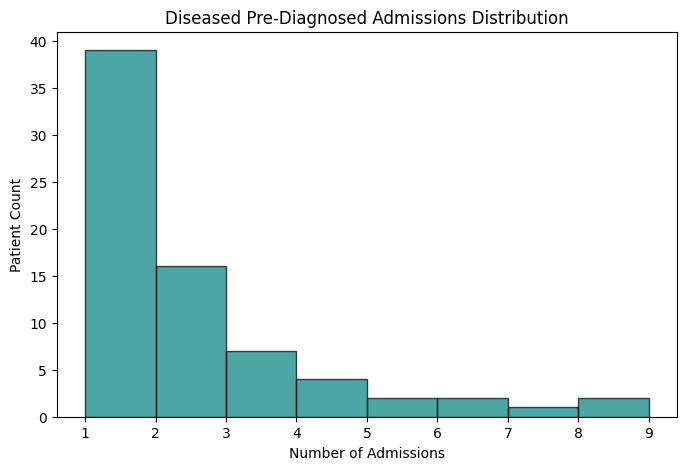

In [2]:
print("\n" + "="*50)
print("  PHASE 1: FEATURE CLEANING & INITIALIZATION")
print("="*50 + "\n")

# Cleaning feature labels from Chi-Squared selection
reduced_features['Feature'] = reduced_features['Feature'].apply(lambda x: x.split(':')[0] if isinstance(x, str) else x)
reduced_features['Feature'] = reduced_features['Feature'].apply(lambda x: x.split(' ', 1)[-1] if ' ' in str(x) else x)
print(f"[INFO] Unique features after Chi-Squared Filtering: {reduced_features['Feature'].nunique()}")

# Setup Patients and Random Seed
PATIENT_GENDER = PATIENTS[['SUBJECT_ID', 'GENDER']].copy()  # preserved for descriptive analysis
PATIENTS = PATIENTS[['SUBJECT_ID','DOB']]
PATIENTS['DOB'] = pd.to_datetime(PATIENTS['DOB'], errors='coerce')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("\n" + "-"*50)
print("  PHASE 2: TARGET & CONTROL COHORT DEFINITION")
print("-"*50 + "\n")

DIAGNOSES_ICD = DIAGNOSES_ICD.dropna(subset=['ICD9_CODE'])
PROCEDURES_ICD = PROCEDURES_ICD.dropna(subset=['ICD9_CODE'])

# Target: Bacterial Endocarditis
my_icd9_code = ['4210'] 
PROCEDURES_ICD['ICD9_CODE'] = PROCEDURES_ICD['ICD9_CODE'].astype(str).str.zfill(4)

# Merging descriptions for better readability in analysis
DIAGNOSES_ICD = DIAGNOSES_ICD.merge(ICD_9_DESCRIPTIONS[['ICD9','Description']], left_on='ICD9_CODE', right_on='ICD9', how='left')
PROCEDURES_ICD = PROCEDURES_ICD.merge(ICD_9_DESCRIPTIONS[['ICD9','Description']], left_on='ICD9_CODE', right_on='ICD9', how='left')

# Format ICD9_FULL as 'Code: Description'
for df in [DIAGNOSES_ICD, PROCEDURES_ICD]:
    df['ICD9_FULL'] = df['ICD9_CODE']
    mask = (df['Description'].notna()) & (df['Description'] != '')
    df.loc[mask, 'ICD9_FULL'] = df['ICD9_CODE'] + ": " + df['Description']
    df.drop(columns=['ICD9', 'Description'], inplace=True)

print(f"[DATA] Total Unique Diagnoses: {DIAGNOSES_ICD['ICD9_CODE'].nunique()}")
print(f"[DATA] Total Unique Procedures: {PROCEDURES_ICD['ICD9_CODE'].nunique()}")

DISEASE_SUBJECT_ID = DIAGNOSES_ICD.loc[DIAGNOSES_ICD["ICD9_CODE"].isin(my_icd9_code), "SUBJECT_ID"].unique()
disease_text_ids = ADMISSIONS[ADMISSIONS['DIAGNOSIS'].str.contains('BACTERIAL ENDOCARDITIS', na=False)]['SUBJECT_ID'].unique()
EXCLUDE_FROM_CONTROLS = np.union1d(DISEASE_SUBJECT_ID, disease_text_ids)

CONTROL_SUBJECT_ID = DIAGNOSES_ICD.loc[~DIAGNOSES_ICD["SUBJECT_ID"].isin(EXCLUDE_FROM_CONTROLS), "SUBJECT_ID"].unique()

DISEASE_HADM_ID = DIAGNOSES_ICD.loc[DIAGNOSES_ICD["ICD9_CODE"].isin(my_icd9_code), "HADM_ID"].unique()

print(f"[INFO] Patients excluded from controls: {len(EXCLUDE_FROM_CONTROLS)}")

print("\n" + "-"*50)
print("  PHASE 3: COMPRESSING TEMPORAL DATA")
print("-"*50 + "\n")

# Filter by Chi-Squared features and minimum prevalence (>7)
DIAGNOSES_ICD = DIAGNOSES_ICD[DIAGNOSES_ICD['ICD9_CODE'].isin(reduced_features['Feature'])]
PROCEDURES_ICD = PROCEDURES_ICD[PROCEDURES_ICD['ICD9_CODE'].isin(reduced_features['Feature'])]
DIAGNOSES_ICD = DIAGNOSES_ICD.groupby('ICD9_CODE').filter(lambda x: x['SUBJECT_ID'].nunique() > 7)

# Grouping codes into lists per admission
def compress_codes(df, sub_ids, col_name):
    filtered = df[df['SUBJECT_ID'].isin(sub_ids)]
    if col_name == 'DIAGNOSES':
        filtered = filtered[~filtered['ICD9_CODE'].isin(my_icd9_code)]
    return filtered.sort_values(['HADM_ID','SEQ_NUM']).groupby(['SUBJECT_ID','HADM_ID'])['ICD9_FULL'].apply(list).reset_index(name=col_name)

PATIENT_DIAGNOSES = compress_codes(DIAGNOSES_ICD, DISEASE_SUBJECT_ID, 'DIAGNOSES')
CONTROL_DIAGNOSES = compress_codes(DIAGNOSES_ICD, CONTROL_SUBJECT_ID, 'DIAGNOSES')
PATIENT_PROCEDURES = compress_codes(PROCEDURES_ICD, DISEASE_SUBJECT_ID, 'PROCEDURE TYPE')
CONTROL_PROCEDURES = compress_codes(PROCEDURES_ICD, CONTROL_SUBJECT_ID, 'PROCEDURE TYPE')

display(PATIENT_DIAGNOSES.head())

# Merging into Admission master tables
PATIENT_ADMISSIONS_MERGED = ADMISSIONS[ADMISSIONS['SUBJECT_ID'].isin(DISEASE_SUBJECT_ID)]\
    .merge(PATIENT_DIAGNOSES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(PATIENT_PROCEDURES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(PATIENTS, on=["SUBJECT_ID"], how="left")

CONTROL_ADMISSIONS_MERGED = ADMISSIONS[ADMISSIONS['SUBJECT_ID'].isin(CONTROL_SUBJECT_ID)]\
    .merge(CONTROL_DIAGNOSES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(CONTROL_PROCEDURES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(PATIENTS, on=["SUBJECT_ID"], how="left")

for df in [PATIENT_ADMISSIONS_MERGED, CONTROL_ADMISSIONS_MERGED]:
    df.rename(columns={"DIAGNOSIS": "DIAGNOSIS (LABEL)","DIAGNOSES": "DIAGNOSIS (ICD_9)"}, inplace=True)
    if 'ROW_ID' in df.columns: df.drop(['ROW_ID'], axis=1, inplace=True)
    df['ADMITTIME'] = pd.to_datetime(df["ADMITTIME"], errors="coerce")

print("\n" + "-"*50)
print("  PHASE 4: PRE-DIAGNOSTIC FILTERING & INDEXING")
print("-"*50 + "\n")

# Find first diagnosis time for cases
DISEASE_FIRST_ADMISSIONS = PATIENT_ADMISSIONS_MERGED[PATIENT_ADMISSIONS_MERGED['HADM_ID'].isin(DISEASE_HADM_ID)]\
    .groupby('SUBJECT_ID', as_index=False)['ADMITTIME'].min().rename(columns={"ADMITTIME": "Comparator"})

# Restrict cases to history BEFORE the diagnosis
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED.merge(DISEASE_FIRST_ADMISSIONS, on='SUBJECT_ID', how="left")
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED[PATIENT_ADMISSIONS_MERGED['ADMITTIME'] < PATIENT_ADMISSIONS_MERGED['Comparator']]
PATIENT_ADMISSIONS_MERGED.drop(['Comparator'], axis=1, inplace=True)

# Sorting and event indexing (T-1, T-2...)
for df in [PATIENT_ADMISSIONS_MERGED, CONTROL_ADMISSIONS_MERGED]:
    df.sort_values(['SUBJECT_ID', 'ADMITTIME'], ascending=[True, False], inplace=True)
    df['event_index'] = (df.groupby('SUBJECT_ID').cumcount() + 1) * -1

diseased_counts = PATIENT_ADMISSIONS_MERGED.groupby('SUBJECT_ID')['HADM_ID'].nunique()
print(f"[RESULT] Cases with 1 prior admission: {(diseased_counts == 1).sum()}")
print(f"[RESULT] Cases with 2+ prior admissions: {(diseased_counts >= 2).sum()}")

# Plotting Admission Distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(diseased_counts, bins=range(1, 10), alpha=0.7, color='teal', edgecolor='black')
ax.set_title('Diseased Pre-Diagnosed Admissions Distribution')
ax.set_xlabel('Number of Admissions')
ax.set_ylabel('Patient Count')
plt.savefig('cases_history_dist.png')
print("\n[PLOT] Saved 'cases_history_dist.png' to visualize diseased cohort history.")

print("\n" + "-"*50)
print("  PHASE 5: CONTROL SUBSAMPLING & GAPS")
print("-"*50 + "\n")

# We are matching the ratio of single admission patients to double admission patients for the controls group, based on the ratio found in the diseased group to reduce single admissions in controls which
# likely represent milder patient phenotypes
diseased_1, diseased_2 = (diseased_counts == 1).sum(), (diseased_counts == 2).sum()
control_counts = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID')['HADM_ID'].nunique()
num_to_keep = round(diseased_1/diseased_2 * (control_counts == 2).sum())

c_ids_1 = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID').filter(lambda x: x['HADM_ID'].nunique() == 1)['SUBJECT_ID'].unique()
sampled_c1_ids = np.random.choice(c_ids_1, size=num_to_keep, replace=False)
c_ids_multi = control_counts[(control_counts >= 2) & (control_counts < 9)].index

CONTROL_SUBJECT_ID = np.concatenate([sampled_c1_ids, c_ids_multi])

CONTROL_ADMISSIONS_MERGED = CONTROL_ADMISSIONS_MERGED[CONTROL_ADMISSIONS_MERGED['SUBJECT_ID'].isin(np.concatenate([sampled_c1_ids, c_ids_multi]))]
reduced_control_counts = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID')['HADM_ID'].nunique()

# Admissions gap calculations (not used in modeling, can be implemented in future iterations for temporal analysis or as a descriptive feature)
for df, label in [(PATIENT_ADMISSIONS_MERGED, 'Cases'), (CONTROL_ADMISSIONS_MERGED, 'Controls')]:
    if label == 'Cases':
        df['Gap'] = df.groupby(['SUBJECT_ID'])['ADMITTIME'].diff(periods=-1).abs().dt.days
    else:
        df['Gap'] = df.groupby('SUBJECT_ID')['ADMITTIME'].diff(periods=1).dt.days.abs()
    
    df['Recent Admission Gaps'] = df.groupby('SUBJECT_ID')['Gap'].transform('last').fillna(3650)
    df.drop(columns=['Gap'], inplace=True)

print(f"\n[FINAL] Cases: {PATIENT_ADMISSIONS_MERGED.shape} | Controls: {CONTROL_ADMISSIONS_MERGED.shape}")
print("\n" + "="*50)
print("  CHUNK 1 COMPLETE")
print("="*50 + "\n")


--------------------------------------------------
  PHASE 4: PRE-DIAGNOSTIC FILTERING & INDEXING
--------------------------------------------------

[RESULT] Cases with 1 prior admission: 39
[RESULT] Cases with 2+ prior admissions: 34

[PLOT] Saved 'cases_history_dist.png' to visualize diseased cohort history.

--------------------------------------------------
  PHASE 5: CONTROL SUBSAMPLING & GAPS
--------------------------------------------------


[FINAL] Cases: (153, 23) | Controls: (30862, 23)

  CHUNK 1 COMPLETE



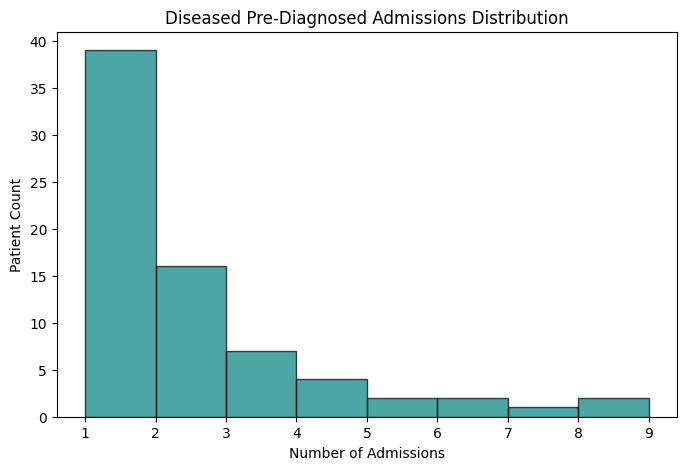

In [3]:

PATIENT_DIAGNOSES = compress_codes(DIAGNOSES_ICD, DISEASE_SUBJECT_ID, 'DIAGNOSES')
CONTROL_DIAGNOSES = compress_codes(DIAGNOSES_ICD, CONTROL_SUBJECT_ID, 'DIAGNOSES')
PATIENT_PROCEDURES = compress_codes(PROCEDURES_ICD, DISEASE_SUBJECT_ID, 'PROCEDURE TYPE')
CONTROL_PROCEDURES = compress_codes(PROCEDURES_ICD, CONTROL_SUBJECT_ID, 'PROCEDURE TYPE')

# Merging into Admission master tables
PATIENT_ADMISSIONS_MERGED = ADMISSIONS[ADMISSIONS['SUBJECT_ID'].isin(DISEASE_SUBJECT_ID)]\
    .merge(PATIENT_DIAGNOSES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(PATIENT_PROCEDURES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(PATIENTS, on=["SUBJECT_ID"], how="left")

CONTROL_ADMISSIONS_MERGED = ADMISSIONS[ADMISSIONS['SUBJECT_ID'].isin(CONTROL_SUBJECT_ID)]\
    .merge(CONTROL_DIAGNOSES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(CONTROL_PROCEDURES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(PATIENTS, on=["SUBJECT_ID"], how="left")

for df in [PATIENT_ADMISSIONS_MERGED, CONTROL_ADMISSIONS_MERGED]:
    df.rename(columns={"DIAGNOSIS": "DIAGNOSIS (LABEL)","DIAGNOSES": "DIAGNOSIS (ICD_9)"}, inplace=True)
    if 'ROW_ID' in df.columns: df.drop(['ROW_ID'], axis=1, inplace=True)
    df['ADMITTIME'] = pd.to_datetime(df["ADMITTIME"], errors="coerce")

print("\n" + "-"*50)
print("  PHASE 4: PRE-DIAGNOSTIC FILTERING & INDEXING")
print("-"*50 + "\n")

# Find first diagnosis time for cases
DISEASE_FIRST_ADMISSIONS = PATIENT_ADMISSIONS_MERGED[PATIENT_ADMISSIONS_MERGED['HADM_ID'].isin(DISEASE_HADM_ID)]\
    .groupby('SUBJECT_ID', as_index=False)['ADMITTIME'].min().rename(columns={"ADMITTIME": "Comparator"})

# Restrict cases to history BEFORE the diagnosis
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED.merge(DISEASE_FIRST_ADMISSIONS, on='SUBJECT_ID', how="left")
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED[PATIENT_ADMISSIONS_MERGED['ADMITTIME'] < PATIENT_ADMISSIONS_MERGED['Comparator']]
PATIENT_ADMISSIONS_MERGED.drop(['Comparator'], axis=1, inplace=True)

# Sorting and event indexing (T-1, T-2...)
for df in [PATIENT_ADMISSIONS_MERGED, CONTROL_ADMISSIONS_MERGED]:
    df.sort_values(['SUBJECT_ID', 'ADMITTIME'], ascending=[True, False], inplace=True)
    df['event_index'] = (df.groupby('SUBJECT_ID').cumcount() + 1) * -1

diseased_counts = PATIENT_ADMISSIONS_MERGED.groupby('SUBJECT_ID')['HADM_ID'].nunique()
print(f"[RESULT] Cases with 1 prior admission: {(diseased_counts == 1).sum()}")
print(f"[RESULT] Cases with 2+ prior admissions: {(diseased_counts >= 2).sum()}")

# Plotting Admission Distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(diseased_counts, bins=range(1, 10), alpha=0.7, color='teal', edgecolor='black')
ax.set_title('Diseased Pre-Diagnosed Admissions Distribution')
ax.set_xlabel('Number of Admissions')
ax.set_ylabel('Patient Count')
plt.savefig('cases_history_dist.png')
print("\n[PLOT] Saved 'cases_history_dist.png' to visualize diseased cohort history.")

print("\n" + "-"*50)
print("  PHASE 5: CONTROL SUBSAMPLING & GAPS")
print("-"*50 + "\n")

# We are matching the ratio of single admission patients to double admission patients for the controls group, based on the ratio found in the diseased group to reduce single admissions in controls which
# likely represent milder patient phenotypes
diseased_1, diseased_2 = (diseased_counts == 1).sum(), (diseased_counts == 2).sum()
control_counts = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID')['HADM_ID'].nunique()
num_to_keep = round(diseased_1/diseased_2 * (control_counts == 2).sum())

c_ids_1 = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID').filter(lambda x: x['HADM_ID'].nunique() == 1)['SUBJECT_ID'].unique()
sampled_c1_ids = np.random.choice(c_ids_1, size=num_to_keep, replace=False)
c_ids_multi = control_counts[(control_counts >= 2) & (control_counts < 9)].index

CONTROL_SUBJECT_ID = np.concatenate([sampled_c1_ids, c_ids_multi])

CONTROL_ADMISSIONS_MERGED = CONTROL_ADMISSIONS_MERGED[CONTROL_ADMISSIONS_MERGED['SUBJECT_ID'].isin(np.concatenate([sampled_c1_ids, c_ids_multi]))]
reduced_control_counts = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID')['HADM_ID'].nunique()

# Final Gap Calculations
for df, label in [(PATIENT_ADMISSIONS_MERGED, 'Cases'), (CONTROL_ADMISSIONS_MERGED, 'Controls')]:
    if label == 'Cases':
        df['Gap'] = df.groupby(['SUBJECT_ID'])['ADMITTIME'].diff(periods=-1).abs().dt.days
    else:
        df['Gap'] = df.groupby('SUBJECT_ID')['ADMITTIME'].diff(periods=1).dt.days.abs()
    
    df['Recent Admission Gaps'] = df.groupby('SUBJECT_ID')['Gap'].transform('last').fillna(3650)
    df.drop(columns=['Gap'], inplace=True)

print(f"\n[FINAL] Cases: {PATIENT_ADMISSIONS_MERGED.shape} | Controls: {CONTROL_ADMISSIONS_MERGED.shape}")
print("\n" + "="*50)
print("  CHUNK 1 COMPLETE")
print("="*50 + "\n")

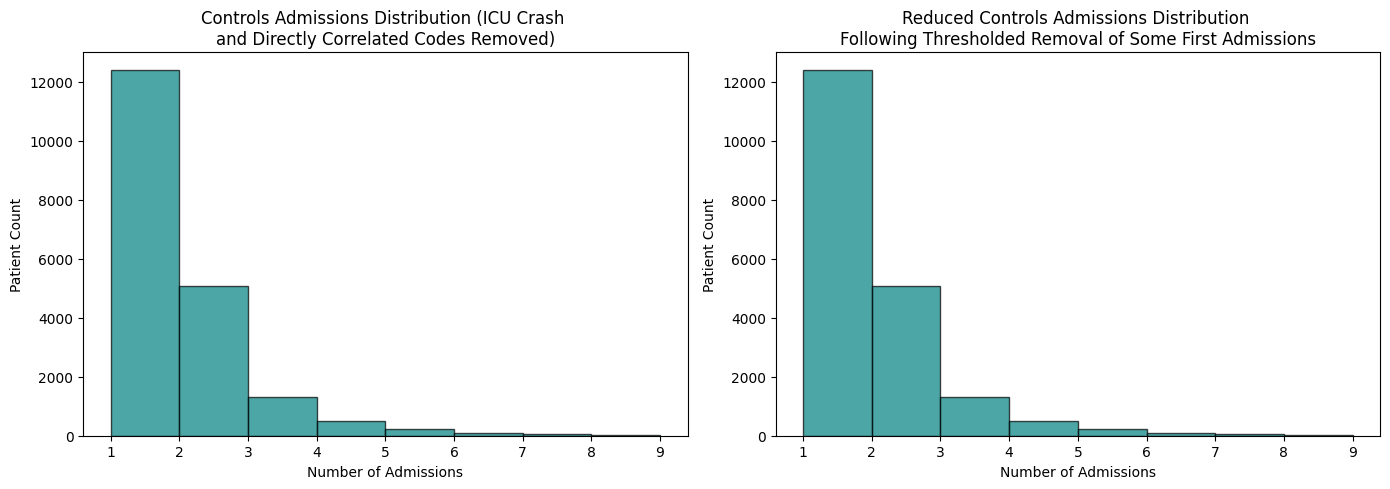


[PLOT] Saved and displayed side-by-side admission history distributions.


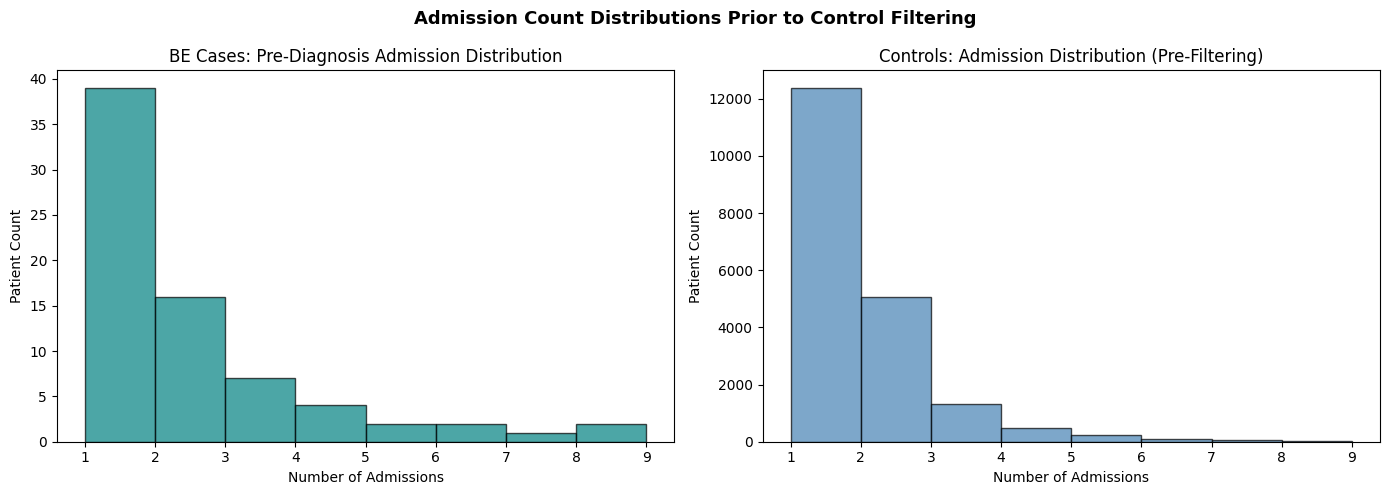


[PLOT] Saved 'cases_vs_controls_prefilter_dist.png'


In [4]:
# Create a figure with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plotting the first (left) distribution
axs[0].hist(control_counts, bins=range(1, 10), alpha=0.7, color='teal', edgecolor='black')
axs[0].set_title('Controls Admissions Distribution (ICU Crash \nand Directly Correlated Codes Removed)')
axs[0].set_xlabel('Number of Admissions')
axs[0].set_ylabel('Patient Count')

# Plotting the second (right) distribution (identical copy)
axs[1].hist(reduced_control_counts, bins=range(1, 10), alpha=0.7, color='teal', edgecolor='black')
axs[1].set_title('Reduced Controls Admissions Distribution \nFollowing Thresholded Removal of Some First Admissions')
axs[1].set_xlabel('Number of Admissions')
axs[1].set_ylabel('Patient Count')

plt.tight_layout()
plt.savefig('cases_history_dist_dual.png')
plt.show() # Ensures visibility in Jupyter Notebook

print("\n[PLOT] Saved and displayed side-by-side admission history distributions.")
#Most recent visits in the dataset, and for the one timers see when their most recent admission is relative to start of dataset
#Two models - one for only only one visit and then another for those with two or more visits
# pull performance metrics

# Side-by-side: Cases vs Controls (pre-filtering)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(diseased_counts, bins=range(1, 10), alpha=0.7, color='teal', edgecolor='black')
axes[0].set_title('BE Cases: Pre-Diagnosis Admission Distribution')
axes[0].set_xlabel('Number of Admissions')
axes[0].set_ylabel('Patient Count')

axes[1].hist(control_counts, bins=range(1, 10), alpha=0.7, color='steelblue', edgecolor='black')
axes[1].set_title('Controls: Admission Distribution (Pre-Filtering)')
axes[1].set_xlabel('Number of Admissions')
axes[1].set_ylabel('Patient Count')

plt.suptitle('Admission Count Distributions Prior to Control Filtering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cases_vs_controls_prefilter_dist.png')
plt.show()
print("\n[PLOT] Saved 'cases_vs_controls_prefilter_dist.png'")

In [5]:
# --- ENHANCED CHUNK 2 (FORMATTED) ---
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt

print("\n" + "="*50)
print("  PHASE 6: CLINICAL DATA PREPROCESSING & CLEANING")
print("="*50 + "\n")

def preprocess_clinical_data(df):
    df = df.copy()
    
    # Calculate length of stay in days
    df['ADMITTIME'] = pd.to_datetime(df['ADMITTIME'])
    df['DISCHTIME'] = pd.to_datetime(df['DISCHTIME'])
    df['LOS_DAYS'] = round((df['DISCHTIME'] - df['ADMITTIME']).dt.total_seconds() / 86400)
    
    # Calculate Age and cap elderly at 92, drop newborns
    df['Age'] = (df['ADMITTIME'] - df['DOB']).dt.days // 365

    # DROP records with negative LOS or Age
    initial_count = len(df)
    df = df[(df['LOS_DAYS'] >= 0) & (df['Age'] > 0)]
    dropped_erroneous = initial_count - len(df)

    df.loc[df['Age'] > 100, 'Age'] = 92 
    
    # Define Leaky/Identifier columns to drop
    cols_to_drop = [
        'HADM_ID', 'ADMITTIME', 'DISCHTIME', 
        'DEATHTIME', 'EDREGTIME', 'EDOUTTIME', 'HOSPITAL_EXPIRE_FLAG',
        'DIAGNOSIS (LABEL)', 'HAS_CHARTEVENTS_DATA','DOB'
    ]

    # Drop columns if they exist in the dataframe
    existing_drops = [c for c in cols_to_drop if c in df.columns]
    df_clean = df.drop(columns=existing_drops)
    
    return df_clean, dropped_erroneous, existing_drops

print("[INFO] Cleaning Patient Data...")
PATIENT_CLEAN, p_dropped, p_cols = preprocess_clinical_data(PATIENT_ADMISSIONS_MERGED)
print(f"[RESULT] Dropped {p_dropped} records. Removed {len(p_cols)} leaky columns.")

print("[INFO] Cleaning Control Data...")
CONTROL_CLEAN, c_dropped, c_cols = preprocess_clinical_data(CONTROL_ADMISSIONS_MERGED)
print(f"[RESULT] Dropped {c_dropped} records. Removed {len(c_cols)} leaky columns.")

print("\n" + "-"*50)
print("  PHASE 7: TEMPORAL FEATURE ENGINEERING")
print("-"*50 + "\n")


  PHASE 6: CLINICAL DATA PREPROCESSING & CLEANING

[INFO] Cleaning Patient Data...
[RESULT] Dropped 0 records. Removed 10 leaky columns.
[INFO] Cleaning Control Data...
[RESULT] Dropped 2944 records. Removed 10 leaky columns.

--------------------------------------------------
  PHASE 7: TEMPORAL FEATURE ENGINEERING
--------------------------------------------------



In [6]:
def prepare_patient_level_features(PATIENT_CLEAN, CONTROL_CLEAN):
    from collections import Counter

    # Combine everything into one DF to ensure columns align across all patients
    df = pd.concat([PATIENT_CLEAN, CONTROL_CLEAN], axis=0)

    # Attach event index to code to retain temporal sequence structure (e.g., "T-1 4210")
    def prefix_codes(row, col_name):
        codes = row[col_name]
        if not isinstance(codes, list): return []
        return [f"T{int(row['event_index'])} {code}" for code in codes]

    df['diag_temporal'] = df.apply(lambda x: prefix_codes(x, 'DIAGNOSIS (ICD_9)'), axis=1)
    df['proc_temporal'] = df.apply(lambda x: prefix_codes(x, 'PROCEDURE TYPE'), axis=1)

    # Concatenate temporal codes and demographic maxs into a single row per patient
    patient_df = df.groupby('SUBJECT_ID').agg({
        'diag_temporal': 'sum',
        'proc_temporal': 'sum',
        'LOS_DAYS': 'max',
        'Age': 'max'
    }).sort_index()
    
    # Calculate prevalence specific to our cases and controls subsets
    be_patients_only = patient_df.loc[patient_df.index.isin(DISEASE_SUBJECT_ID)]
    controls_patients_only = patient_df.loc[patient_df.index.isin(CONTROL_SUBJECT_ID)]

    all_be_codes = [code for sublist in be_patients_only['diag_temporal'].apply(set) for code in sublist]
    all_controls_codes = [code for sublist in controls_patients_only['diag_temporal'].apply(set) for code in sublist]

    be_prevalence = (pd.Series(Counter(all_be_codes))).sort_values(ascending=False)
    controls_prevalence = (pd.Series(Counter(all_controls_codes))).sort_values(ascending=False)

    # Impute NAs for numericals
    X_num = patient_df[['LOS_DAYS', 'Age']].fillna(0)    
  
    return X_num, patient_df['diag_temporal'], patient_df['proc_temporal'], patient_df.index, df, be_prevalence, controls_prevalence

num_f, diag_list, proc_list, patient_ids, full_df, be_prevalence, controls_prevalence = prepare_patient_level_features(PATIENT_CLEAN, CONTROL_CLEAN)

print(f"[INFO] Temporal prefixes applied. Extracted features for {len(patient_ids)} total unique patients.")

# ----------------------------------

print("\n" + "-"*50)
print("  PHASE 8: MATRIX VECTORIZATION (ONE-HOT ENCODING)")
print("-"*50 + "\n")

# Prepare sparse one-hot encoding for massive feature lists
mlb_diag = MultiLabelBinarizer(sparse_output=True).fit(diag_list)
mlb_proc = MultiLabelBinarizer(sparse_output=True).fit(proc_list)

print(f"[MATRIX] Transformed Diagnoses into {len(mlb_diag.classes_)} unique features.")
print(f"[MATRIX] Transformed Procedures into {len(mlb_proc.classes_)} unique features.")
print(f"[MATRIX] Numerical Features length: {num_f.shape[1]}")

# Stack all feature matrices horizontally
X_sparse = hstack([
    mlb_diag.transform(diag_list),
    mlb_proc.transform(proc_list),
    csr_matrix(num_f.astype(float))
])

# Create binary target array
y = np.array([1 if pid in DISEASE_SUBJECT_ID else 0 for pid in patient_ids])

print("\n" + "="*50)
print("  CHUNK 2 COMPLETE: FINAL MODELING SET READY")
print("="*50)
print(f"Final Patient-Level X Matrix Shape: {X_sparse.shape}")
print(f"Target Array (y) Shape: {y.shape}")
print(f"Class Balance -> Total Patients: {len(y)} | Diseased Cases: {sum(y)} | Controls: {len(y) - sum(y)}\n")


[INFO] Temporal prefixes applied. Extracted features for 17053 total unique patients.

--------------------------------------------------
  PHASE 8: MATRIX VECTORIZATION (ONE-HOT ENCODING)
--------------------------------------------------

[MATRIX] Transformed Diagnoses into 571 unique features.
[MATRIX] Transformed Procedures into 333 unique features.
[MATRIX] Numerical Features length: 2

  CHUNK 2 COMPLETE: FINAL MODELING SET READY
Final Patient-Level X Matrix Shape: (17053, 906)
Target Array (y) Shape: (17053,)
Class Balance -> Total Patients: 17053 | Diseased Cases: 73 | Controls: 16980



In [7]:
print("Actual BE Patient Profile:\n", be_prevalence.head(15))

Actual BE Patient Profile:
 T-1 4280: CHF NOS                      33
T-1 42731: Atrial fibrillation         26
T-1 4019: Hypertension NOS             25
T-1 41401: Crnry athrscl natve vssl    20
T-2 42731: Atrial fibrillation         16
T-2 40391: Hyp kid NOS w cr kid V      12
T-1 40391: Hyp kid NOS w cr kid V      12
T-1 5849: Acute kidney failure NOS     12
T-1 V5861: Long-term use anticoagul    11
T-2 4280: CHF NOS                      11
T-1 4241: Aortic valve disorder        11
T-3 42731: Atrial fibrillation         10
T-1 5856: End stage renal disease      10
T-2 41401: Crnry athrscl natve vssl     9
T-3 40391: Hyp kid NOS w cr kid V       9
dtype: int64


In [8]:
print("Controls Patient Profile:\n", controls_prevalence.head(15))

Controls Patient Profile:
 T-1 4019: Hypertension NOS             6941
T-1 4280: CHF NOS                      4524
T-1 42731: Atrial fibrillation         4504
T-1 41401: Crnry athrscl natve vssl    4049
T-1 5849: Acute kidney failure NOS     3199
T-2 4019: Hypertension NOS             2779
T-1 5990: Urin tract infection NOS     2275
T-1 53081: Esophageal reflux           2184
T-2 4280: CHF NOS                      2109
T-2 42731: Atrial fibrillation         1837
T-1 2859: Anemia NOS                   1835
T-1 486: Pneumonia, organism NOS       1726
T-2 41401: Crnry athrscl natve vssl    1644
T-1 2762: Acidosis                     1628
T-1 99592: Severe sepsis               1517
dtype: int64



  COHORT DESCRIPTIVE ANALYSIS

Characteristic               Positive / BE (n=336)        Negative / Controls (n=19685)    p-value      Sig
------------------------------------------------------------------------------------------------------------------------
Female, n (%)                108 (32.1%)                  8694 (44.2%)                     0.0000       ***
Male, n (%)                  228 (67.9%)                  10991 (55.8%)                    0.0000       ***
Age, median [IQR]            68.0 [54.0-77.0]             66.0 [53.0-78.0]                 0.9895       ns
LOS (days), median [IQR]     13.0 [7.0-24.0]              9.0 [5.0-15.0]                   0.0018       **

Interpretation guide:
- Chi-squared tests whether the categorical sex distribution is the same between cohorts.
- Mann-Whitney U tests whether the continuous distributions are the same between cohorts.
- Small p-values suggest the null hypothesis of equal distributions is unlikely.
- Significance: *** p<0.0

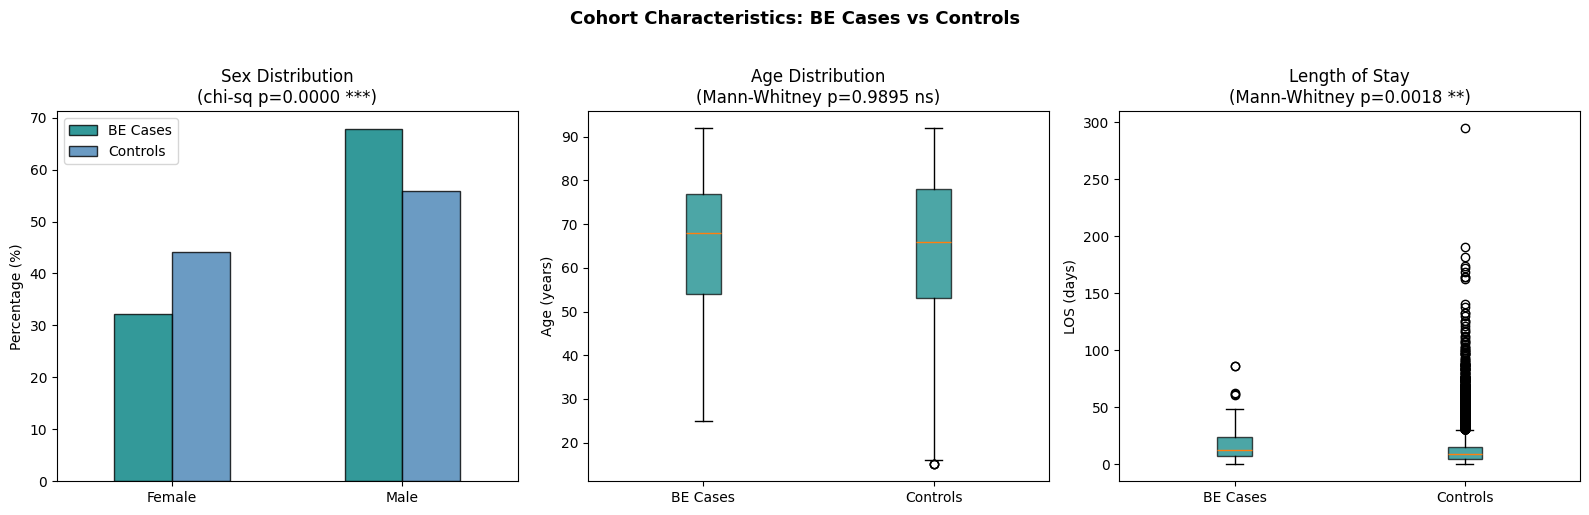

[PLOT] Saved 'cohort_descriptive_analysis.png'


In [9]:
# --- COHORT DESCRIPTIVE ANALYSIS ---
from scipy import stats

print("\n" + "="*50)
print("  COHORT DESCRIPTIVE ANALYSIS")
print("="*50 + "\n")

# Positive class = BE cases; Negative class = controls
cases_subj = pd.DataFrame({'SUBJECT_ID': DISEASE_SUBJECT_ID})
controls_subj = pd.DataFrame({'SUBJECT_ID': CONTROL_SUBJECT_ID})

cases_demo = cases_subj.merge(PATIENT_GENDER, on='SUBJECT_ID', how='left')
controls_demo = controls_subj.merge(PATIENT_GENDER, on='SUBJECT_ID', how='left')

# Patient-level age and LOS (max per patient, from cleaned dfs)
cases_age = PATIENT_CLEAN.groupby('SUBJECT_ID')['Age'].max()
controls_age = CONTROL_CLEAN.groupby('SUBJECT_ID')['Age'].max()
cases_los = PATIENT_CLEAN.groupby('SUBJECT_ID')['LOS_DAYS'].max()
controls_los = CONTROL_CLEAN.groupby('SUBJECT_ID')['LOS_DAYS'].max()

cases_demo = cases_demo.merge(cases_age.reset_index(), on='SUBJECT_ID', how='left')
controls_demo = controls_demo.merge(controls_age.reset_index(), on='SUBJECT_ID', how='left')
cases_demo = cases_demo.merge(cases_los.reset_index(), on='SUBJECT_ID', how='left')
controls_demo = controls_demo.merge(controls_los.reset_index(), on='SUBJECT_ID', how='left')

n_cases = len(cases_demo)
n_controls = len(controls_demo)

# --- Null hypotheses ---
# H0_gender: Sex distribution is the same across BE cases and controls.
# H0_age: Age distributions are the same across BE cases and controls.
# H0_los: LOS distributions are the same across BE cases and controls.

# --- Gender ---
n_cases_f = (cases_demo['GENDER'] == 'F').sum()
n_cases_m = (cases_demo['GENDER'] == 'M').sum()
n_controls_f = (controls_demo['GENDER'] == 'F').sum()
n_controls_m = (controls_demo['GENDER'] == 'M').sum()
pct_cases_f = n_cases_f / n_cases if n_cases else np.nan
pct_cases_m = n_cases_m / n_cases if n_cases else np.nan
pct_controls_f = n_controls_f / n_controls if n_controls else np.nan
pct_controls_m = n_controls_m / n_controls if n_controls else np.nan

contingency_gender = np.array([
    [n_cases_f, n_cases - n_cases_f],
    [n_controls_f, n_controls - n_controls_f]
])
_, p_gender, _, _ = stats.chi2_contingency(contingency_gender)

# --- Age and LOS (Mann-Whitney U) ---
_, p_age = stats.mannwhitneyu(
    cases_demo['Age'].dropna(),
    controls_demo['Age'].dropna(),
    alternative='two-sided'
)
_, p_los = stats.mannwhitneyu(
    cases_demo['LOS_DAYS'].dropna(),
    controls_demo['LOS_DAYS'].dropna(),
    alternative='two-sided'
)

def sig_label(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

def fmt_median_iqr(s):
    s = s.dropna()
    if s.empty:
        return 'NA'
    return f"{s.median():.1f} [{s.quantile(0.25):.1f}-{s.quantile(0.75):.1f}]"

cohort_descriptive_table = pd.DataFrame([
    {
        'Characteristic': 'Female, n (%)',
        'Positive class / BE cases': f"{n_cases_f} ({pct_cases_f*100:.1f}%)",
        'Negative class / Controls': f"{n_controls_f} ({pct_controls_f*100:.1f}%)",
        'Statistical test': 'Chi-squared',
        'Null hypothesis': 'Sex distributions are the same between cohorts',
        'p_value': p_gender,
        'Significance': sig_label(p_gender),
    },
    {
        'Characteristic': 'Male, n (%)',
        'Positive class / BE cases': f"{n_cases_m} ({pct_cases_m*100:.1f}%)",
        'Negative class / Controls': f"{n_controls_m} ({pct_controls_m*100:.1f}%)",
        'Statistical test': 'Chi-squared',
        'Null hypothesis': 'Sex distributions are the same between cohorts',
        'p_value': p_gender,
        'Significance': sig_label(p_gender),
    },
    {
        'Characteristic': 'Age, median [IQR]',
        'Positive class / BE cases': fmt_median_iqr(cases_demo['Age']),
        'Negative class / Controls': fmt_median_iqr(controls_demo['Age']),
        'Statistical test': 'Mann-Whitney U',
        'Null hypothesis': 'Age distributions are the same between cohorts',
        'p_value': p_age,
        'Significance': sig_label(p_age),
    },
    {
        'Characteristic': 'LOS (days), median [IQR]',
        'Positive class / BE cases': fmt_median_iqr(cases_demo['LOS_DAYS']),
        'Negative class / Controls': fmt_median_iqr(controls_demo['LOS_DAYS']),
        'Statistical test': 'Mann-Whitney U',
        'Null hypothesis': 'LOS distributions are the same between cohorts',
        'p_value': p_los,
        'Significance': sig_label(p_los),
    },
])

cohort_descriptive_table.to_csv('cohort_descriptive_table.csv', index=False)

print(f"{'Characteristic':<28} {'Positive / BE (n=%d)' % n_cases:<28} {'Negative / Controls (n=%d)' % n_controls:<32} {'p-value':<12} Sig")
print('-' * 120)
for _, row in cohort_descriptive_table.iterrows():
    print(
        f"{row['Characteristic']:<28} "
        f"{row['Positive class / BE cases']:<28} "
        f"{row['Negative class / Controls']:<32} "
        f"{row['p_value']:<12.4f} {row['Significance']}"
    )

print("\nInterpretation guide:")
print("- Chi-squared tests whether the categorical sex distribution is the same between cohorts.")
print("- Mann-Whitney U tests whether the continuous distributions are the same between cohorts.")
print("- Small p-values suggest the null hypothesis of equal distributions is unlikely.")
print("- Significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
print("[DATA] Saved 'cohort_descriptive_table.csv'")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gender bar chart
gender_data = pd.DataFrame({
    'BE Cases': [pct_cases_f * 100, (1 - pct_cases_f) * 100],
    'Controls': [pct_controls_f * 100, (1 - pct_controls_f) * 100]
}, index=['Female', 'Male'])
gender_data.plot(kind='bar', ax=axes[0], color=['teal', 'steelblue'], edgecolor='black', alpha=0.8)
axes[0].set_title(f"Sex Distribution\n(chi-sq p={p_gender:.4f} {sig_label(p_gender)})")
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0].legend()

# Age boxplot
axes[1].boxplot(
    [cases_demo['Age'].dropna().values, controls_demo['Age'].dropna().values],
    labels=['BE Cases', 'Controls'],
    patch_artist=True,
    boxprops=dict(facecolor='teal', alpha=0.7)
)
axes[1].set_title(f"Age Distribution\n(Mann-Whitney p={p_age:.4f} {sig_label(p_age)})")
axes[1].set_ylabel('Age (years)')

# LOS boxplot
axes[2].boxplot(
    [cases_demo['LOS_DAYS'].dropna().values, controls_demo['LOS_DAYS'].dropna().values],
    labels=['BE Cases', 'Controls'],
    patch_artist=True,
    boxprops=dict(facecolor='teal', alpha=0.7)
)
axes[2].set_title(f"Length of Stay\n(Mann-Whitney p={p_los:.4f} {sig_label(p_los)})")
axes[2].set_ylabel('LOS (days)')

plt.suptitle('Cohort Characteristics: BE Cases vs Controls', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cohort_descriptive_analysis.png', bbox_inches='tight')
plt.show()
print("[PLOT] Saved 'cohort_descriptive_analysis.png'")


In [10]:
# --- ENHANCED CHUNK 3 (MEMORY-OPTIMIZED) ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_selection import chi2
import shap
import math

print("\n" + "="*50)
print("  PHASE 8: MODEL TRAINING & CROSS-VALIDATION")
print("="*50 + "\n")

def ensure_2d_shap_array(shap_output):
    if hasattr(shap_output, 'values'):
        shap_output = shap_output.values
    arr = np.asarray(shap_output)
    if arr.ndim == 3:
        arr = arr[:, :, -1]
    elif arr.ndim == 1:
        arr = arr.reshape(1, -1)
    return arr

def small_dense_rows(X, row_idx):
    X_sub = X[row_idx]
    return X_sub.toarray() if hasattr(X_sub, 'toarray') else np.asarray(X_sub)

from sklearn.metrics import roc_curve

def compute_fold_metrics(y_true, probas):
    from sklearn.metrics import roc_curve
    probas = np.asarray(probas)
    auc_score = roc_auc_score(y_true, probas)
    fpr, tpr, thresholds = roc_curve(y_true, probas)
    j_scores = tpr + (1 - fpr) - 1
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    best_threshold = float(np.clip(best_threshold, 0, 1))
    preds = (probas >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return auc_score, sens, spec, best_threshold

def norm(arr):
    s = arr.sum()
    return arr / s if s > 0 else arr

fold_metrics = []
all_X_te_dfs = []

control_sample_size = min(2800, len(CONTROL_SUBJECT_ID))

# Shuffle and partition controls into non-overlapping chunks
rng_global = np.random.default_rng(42)
shuffled_controls = rng_global.permutation(CONTROL_SUBJECT_ID)
partitions = [shuffled_controls[i:i+control_sample_size]
              for i in range(0, len(shuffled_controls), control_sample_size)]

# Drop last partition if smaller than control_sample_size
if len(partitions[-1]) < control_sample_size:
    partitions = partitions[:-1]

seed_count = len(partitions)


print(f"[INFO] Preparing to run {seed_count} seed iterations (non-overlapping control partitions).")
print(f"[INFO] Control sample size per iteration: {control_sample_size}")

feat_names = [f"DX_{c}" for c in mlb_diag.classes_] + [f"PR_{c}" for c in mlb_proc.classes_] + ['LOS_DAYS', 'Age']

feature_importance_store = {
    'XGBoost': [],
    'DecisionTree': [],
    'RandomForest': [],
    'Lasso': [],
    'Chi2': []
}

model_predictions = {
    'XGBoost': {'y': [], 'probs': []},
    'DecisionTree': {'y': [], 'probs': []},
    'RandomForest': {'y': [], 'probs': []},
    'Lasso': {'y': [], 'probs': []}
}

all_shap_dfs = {
    'XGBoost': [],
    'DecisionTree': [],
    'RandomForest': [],
    'Lasso': []
}

rf_fold_roc_data = []

SHAP_BG_SIZE = 200
SHAP_TEST_SIZE = 300

for seed, sampled_control_ids in enumerate(partitions):
    rng = np.random.default_rng(seed)

    keep_ids = np.concatenate([DISEASE_SUBJECT_ID, sampled_control_ids])
    mask = np.isin(patient_ids, keep_ids)

    X_sparse_seed = X_sparse[mask]
    y_seed = y[mask]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    print("\n" + "-"*40)
    print(f"  SEED ITERATION {seed + 1}/{seed_count}")
    print("-"*40)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sparse_seed, y_seed), start=1):
        scaler = MaxAbsScaler()

        X_tr, X_te = X_sparse_seed[train_idx], X_sparse_seed[test_idx]
        y_tr, y_te = y_seed[train_idx], y_seed[test_idx]
        current_feat_names = feat_names.copy()

        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        chi_vals, _ = chi2(X_tr, y_tr)

        cases_orig = int(np.sum(y_tr))
        controls_orig = int(len(y_tr) - cases_orig)

        xgb = XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            scale_pos_weight=controls_orig/cases_orig,
            max_depth=3,
            random_state=seed,
            eval_metric='logloss'
        )
        xgb.fit(X_tr, y_tr)

        ros = RandomOverSampler(random_state=seed, sampling_strategy=0.1)
        X_tr_res, y_tr_res = ros.fit_resample(X_tr, y_tr)  

        cases_after = int(np.sum(y_tr_res))
        controls_after = int(len(y_tr_res) - cases_after)

        dt = DecisionTreeClassifier(max_depth=5, random_state=seed)
        dt.fit(X_tr_res, y_tr_res)

        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=seed
        )
        rf.fit(X_tr_res, y_tr_res)

        lasso = LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=1.0,
            random_state=seed,
            max_iter=1000
        )
        lasso.fit(X_tr_res, y_tr_res)

        models = {
            'XGBoost': xgb,
            'DecisionTree': dt,
            'RandomForest': rf,
            'Lasso': lasso,
        }

        per_model_messages = []
        for model_name, model in models.items():
            probs = model.predict_proba(X_te)[:, 1]
            auc_score, sens, spec, threshold = compute_fold_metrics(y_te, probs)

            if model_name == 'RandomForest':
                rf_fold_roc_data.append((y_te.copy(), probs.copy()))

            model_predictions[model_name]['y'].extend(y_te.tolist())
            model_predictions[model_name]['probs'].extend(probs.tolist())
            fold_metrics.append({
                'Seed': seed,
                'Fold': fold,
                'Model': model_name,
                'AUC': auc_score,
                'Sens': sens,
                'Spec': spec,
                'Threshold': threshold,
            })
            per_model_messages.append(f"{model_name}: AUC {auc_score:.3f}, Sens {sens:.1%}, Spec {spec:.1%}")

        feature_importance_store['Chi2'].append(pd.DataFrame([norm(chi_vals)], columns=current_feat_names))
        feature_importance_store['XGBoost'].append(pd.DataFrame([norm(xgb.feature_importances_)], columns=current_feat_names))
        feature_importance_store['DecisionTree'].append(pd.DataFrame([norm(dt.feature_importances_)], columns=current_feat_names))
        feature_importance_store['RandomForest'].append(pd.DataFrame([norm(rf.feature_importances_)], columns=current_feat_names))
        feature_importance_store['Lasso'].append(pd.DataFrame([norm(np.abs(lasso.coef_[0]))], columns=current_feat_names))

        bg_n = min(SHAP_BG_SIZE, X_tr.shape[0])
        te_n = min(SHAP_TEST_SIZE, X_te.shape[0])

        bg_idx = rng.choice(X_tr.shape[0], size=bg_n, replace=False)
        te_idx = rng.choice(X_te.shape[0], size=te_n, replace=False)

        X_bg_xgb_dense = small_dense_rows(X_tr, bg_idx)
        X_bg_res_dense = small_dense_rows(X_tr_res, bg_idx)
        X_te_shap_dense = small_dense_rows(X_te, te_idx)

        explainers = {
            'XGBoost': shap.TreeExplainer(xgb, data=X_bg_xgb_dense, feature_perturbation='interventional'),
            'DecisionTree': shap.TreeExplainer(dt, data=X_bg_res_dense, feature_perturbation='interventional'),
            'RandomForest': shap.TreeExplainer(rf, data=X_bg_res_dense, feature_perturbation='interventional'),
            'Lasso': shap.LinearExplainer(lasso, X_bg_res_dense),
        }

        xgb_sv = ensure_2d_shap_array(explainers['XGBoost'](X_te_shap_dense, check_additivity=False))
        dt_sv = ensure_2d_shap_array(explainers['DecisionTree'](X_te_shap_dense, check_additivity=False))
        rf_sv = ensure_2d_shap_array(explainers['RandomForest'](X_te_shap_dense, check_additivity=False))
        lasso_sv = ensure_2d_shap_array(explainers['Lasso'](X_te_shap_dense))

        all_shap_dfs['XGBoost'].append(pd.DataFrame(xgb_sv, columns=current_feat_names))
        all_shap_dfs['DecisionTree'].append(pd.DataFrame(dt_sv, columns=current_feat_names))
        all_shap_dfs['RandomForest'].append(pd.DataFrame(rf_sv, columns=current_feat_names))
        all_shap_dfs['Lasso'].append(pd.DataFrame(lasso_sv, columns=current_feat_names))
        all_X_te_dfs.append(pd.DataFrame(X_te_shap_dense, columns=current_feat_names))

        print(
            f"Fold {fold} | ROS: Cases ({cases_orig}->{cases_after}), Controls ({controls_orig}->{controls_after}) | "
            + ' | '.join(per_model_messages)
            + f" | SHAP sample n={te_n}"
        )

master_xgb = pd.concat(feature_importance_store['XGBoost']).mean().fillna(0)
master_tree = pd.concat(feature_importance_store['DecisionTree']).mean().fillna(0)
master_rf = pd.concat(feature_importance_store['RandomForest']).mean().fillna(0)
master_lasso = pd.concat(feature_importance_store['Lasso']).mean().fillna(0)
master_chi = pd.concat(feature_importance_store['Chi2']).mean().fillna(0)

final_X_te_df = pd.concat(all_X_te_dfs, axis=0).fillna(0).reset_index(drop=True)
final_shap_xgb_df = pd.concat(all_shap_dfs['XGBoost'], axis=0).reindex(columns=final_X_te_df.columns).fillna(0).reset_index(drop=True)
final_shap_tree_df = pd.concat(all_shap_dfs['DecisionTree'], axis=0).reindex(columns=final_X_te_df.columns).fillna(0).reset_index(drop=True)
final_shap_rf_df = pd.concat(all_shap_dfs['RandomForest'], axis=0).reindex(columns=final_X_te_df.columns).fillna(0).reset_index(drop=True)
final_shap_lasso_df = pd.concat(all_shap_dfs['Lasso'], axis=0).reindex(columns=final_X_te_df.columns).fillna(0).reset_index(drop=True)

fold_metrics_df = pd.DataFrame(fold_metrics)
summary_metrics_df = (
    fold_metrics_df
    .groupby('Model')[['AUC', 'Sens', 'Spec', 'Threshold']]
    .agg(['mean', 'std'])
    .round(4)
)
summary_metrics_df.columns = [f"{metric}_{stat}" for metric, stat in summary_metrics_df.columns]
summary_metrics_df = summary_metrics_df.reset_index()
summary_metrics_df.to_csv('model_summary_metrics.csv', index=False)
fold_metrics_df.to_csv('model_fold_metrics.csv', index=False)

print("\n" + "="*50)
print("  PHASE 9: RESULTS AGGREGATION & FEATURE IMPORTANCE")
print("="*50 + "\n")

print("--- FINAL MEAN METRICS (ALL MODELS) ---")
print(summary_metrics_df)

master_feat_df = pd.DataFrame({
    'XGBoost': master_xgb,
    'DecisionTree': master_tree,
    'RandomForest': master_rf,
    'Lasso': master_lasso,
    'Chi2': master_chi
}).reset_index().rename(columns={'index': 'Feature'})

master_feat_df.to_csv('test_features2.csv', index=False)
print("[DATA] Saved feature importances to 'test_features2.csv'.")
print("[DATA] Saved fold-level metrics to 'model_fold_metrics.csv'.")
print("[DATA] Saved summary metrics to 'model_summary_metrics.csv'.")

print("\n" + "="*50)
print("  CHUNK 3 COMPLETE")
print("="*50 + "\n")


  PHASE 8: MODEL TRAINING & CROSS-VALIDATION

[INFO] Preparing to run 7 seed iterations (non-overlapping control partitions).
[INFO] Control sample size per iteration: 2800

----------------------------------------
  SEED ITERATION 1/7
----------------------------------------
Fold 1 | ROS: Cases (58->192), Controls (1927->1927) | XGBoost: AUC 0.757, Sens 73.3%, Spec 72.8% | DecisionTree: AUC 0.530, Sens 6.7%, Spec 99.4% | RandomForest: AUC 0.745, Sens 93.3%, Spec 56.2% | Lasso: AUC 0.773, Sens 93.3%, Spec 64.9% | SHAP sample n=300
Fold 2 | ROS: Cases (58->192), Controls (1927->1927) | XGBoost: AUC 0.637, Sens 86.7%, Spec 42.3% | DecisionTree: AUC 0.520, Sens 100.0%, Spec 4.4% | RandomForest: AUC 0.709, Sens 80.0%, Spec 55.0% | Lasso: AUC 0.621, Sens 66.7%, Spec 61.4% | SHAP sample n=300
Fold 3 | ROS: Cases (59->192), Controls (1927->1927) | XGBoost: AUC 0.762, Sens 71.4%, Spec 78.0% | DecisionTree: AUC 0.557, Sens 14.3%, Spec 96.7% | RandomForest: AUC 0.742, Sens 85.7%, Spec 55.0% | L


  PHASE 10: MODEL EVALUATION & INTERPRETABILITY

[EVAL] Calculating aggregated ROC/AUC across all cross-validation folds for all four models...
[RESULT] XGBoost Aggregated ROC AUC: 0.709
[RESULT] DecisionTree Aggregated ROC AUC: 0.526
[RESULT] RandomForest Aggregated ROC AUC: 0.749
[RESULT] Lasso Aggregated ROC AUC: 0.741


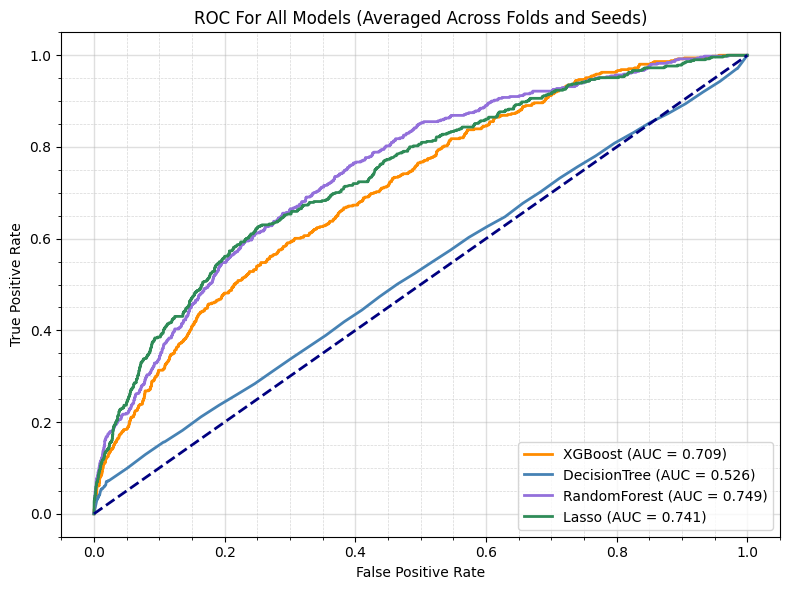

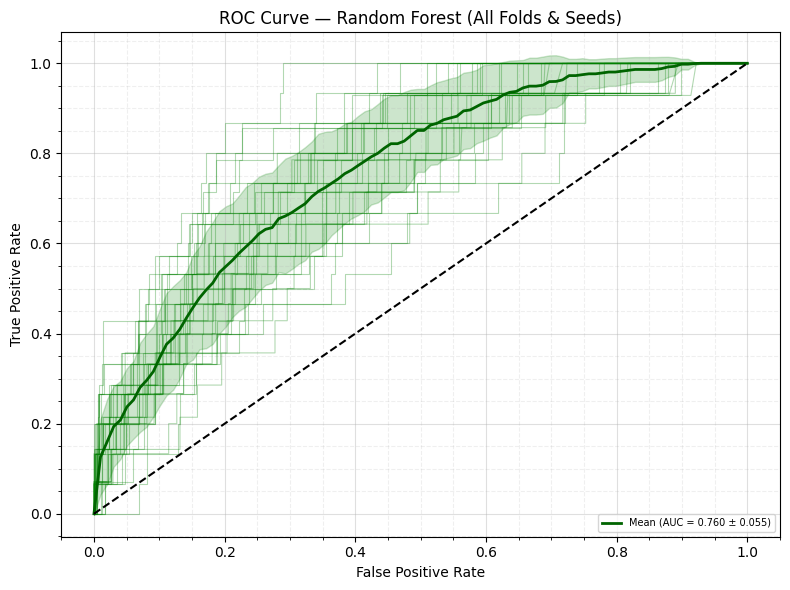

[PLOT] Saved 'roc_curve_rf_per_fold.png'

Aggregated ROC/AUC ranking:
          Model  Aggregated_ROC_AUC
2  RandomForest            0.748572
3         Lasso            0.740529
0       XGBoost            0.709110
1  DecisionTree            0.525677
[PLOT] Saved ROC curve to 'final_roc_curve_all_models.png'
[DATA] Saved aggregated ROC AUC table to 'aggregated_roc_auc_by_model.csv'


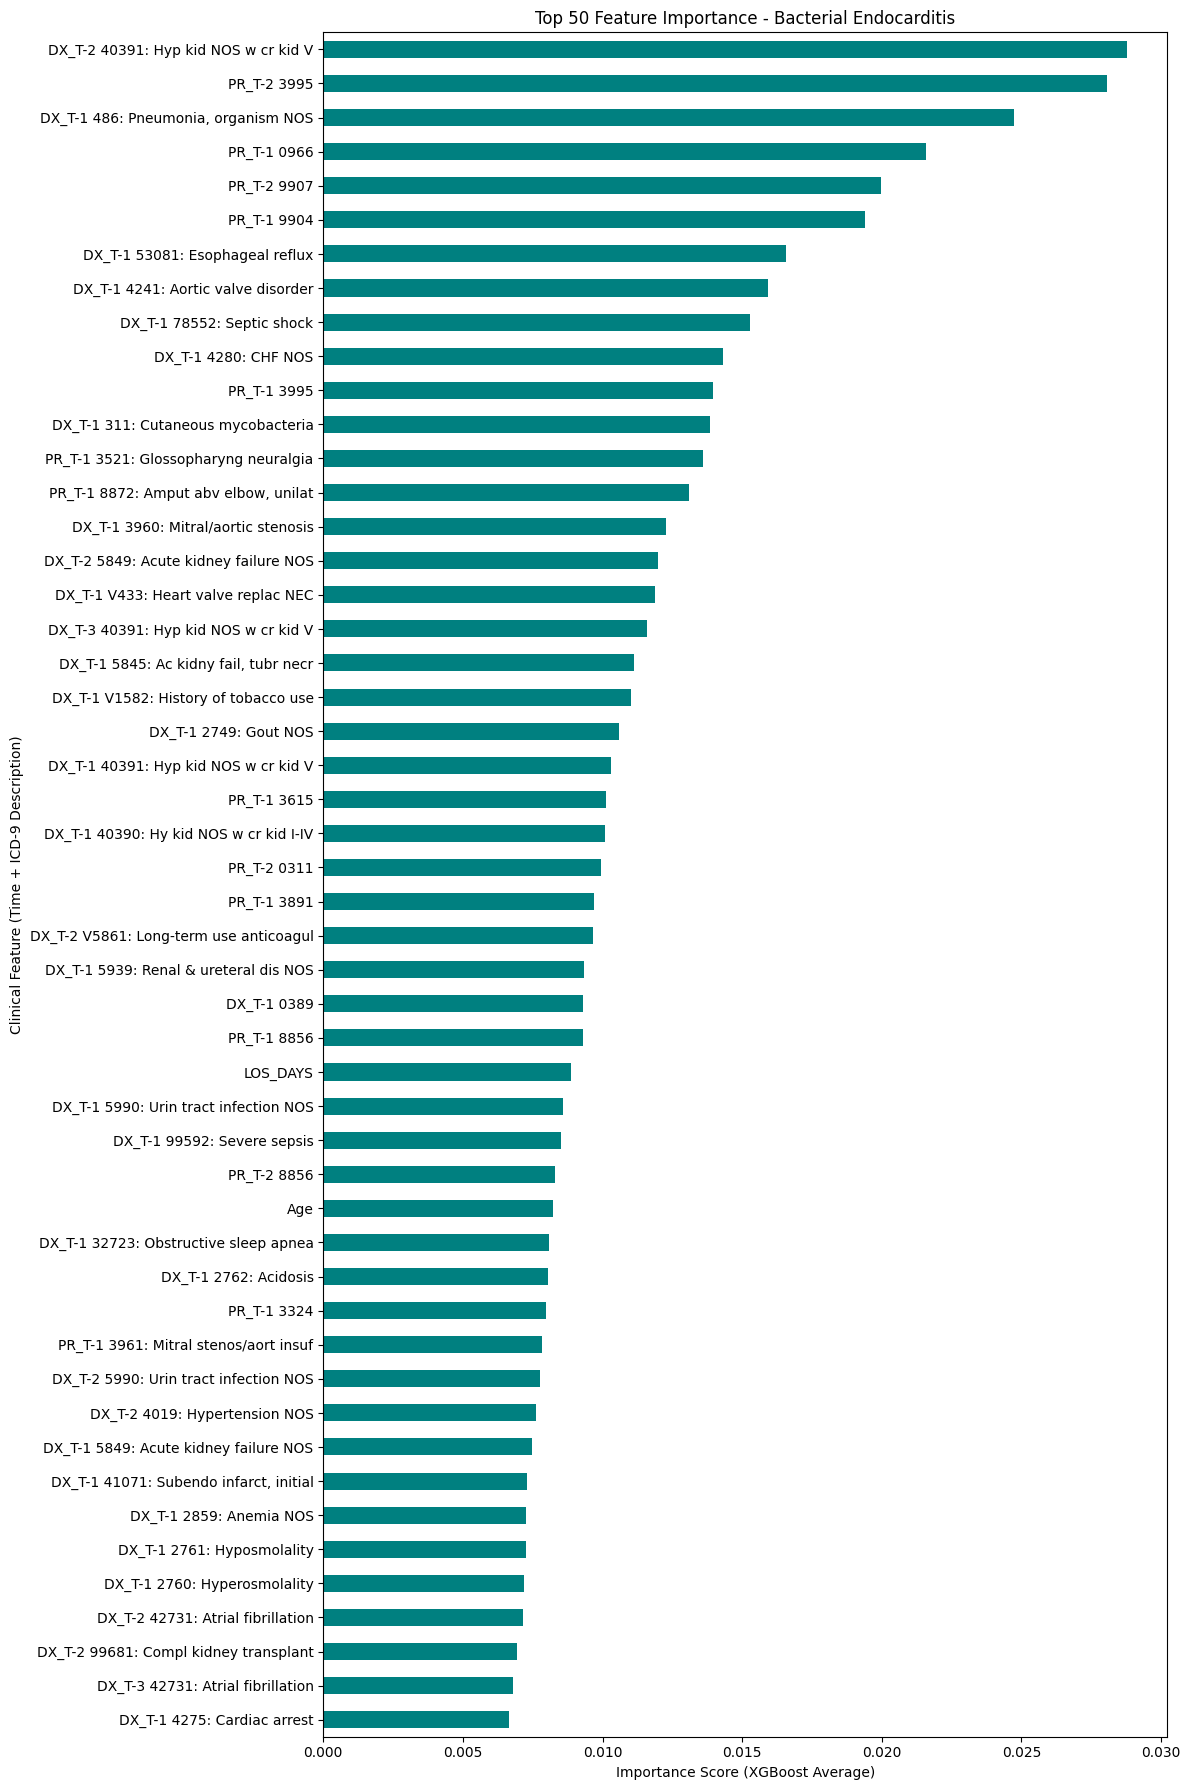


[PLOT] Saved 'top_50_features_xgboost.png' to disk.

[INTERPRET] Generating SHAP summary plots for all four models (test-fold SHAP values)...


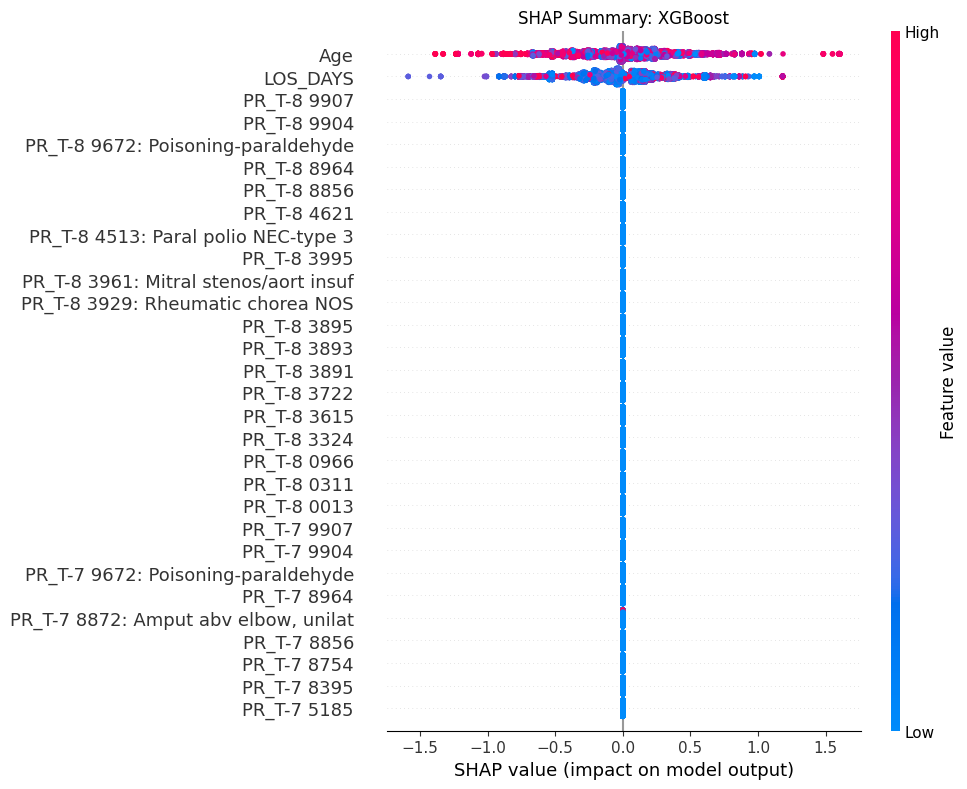

[PLOT] Saved 'shap_summary_xgboost.png'


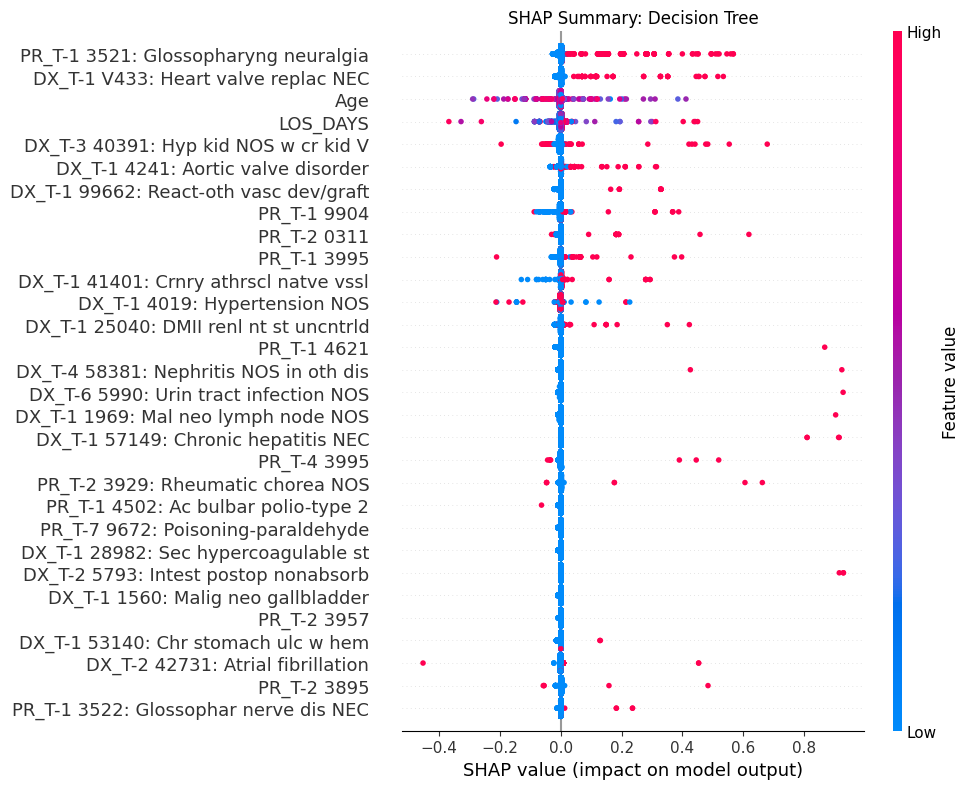

[PLOT] Saved 'shap_summary_decision_tree.png'


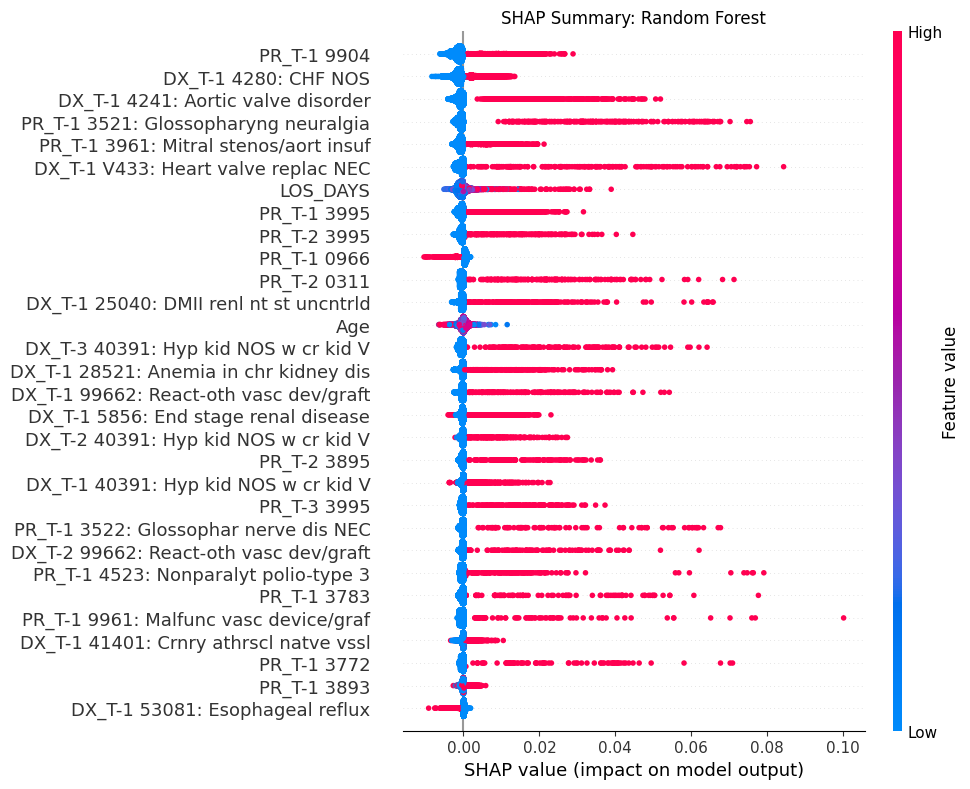

[PLOT] Saved 'shap_summary_random_forest.png'


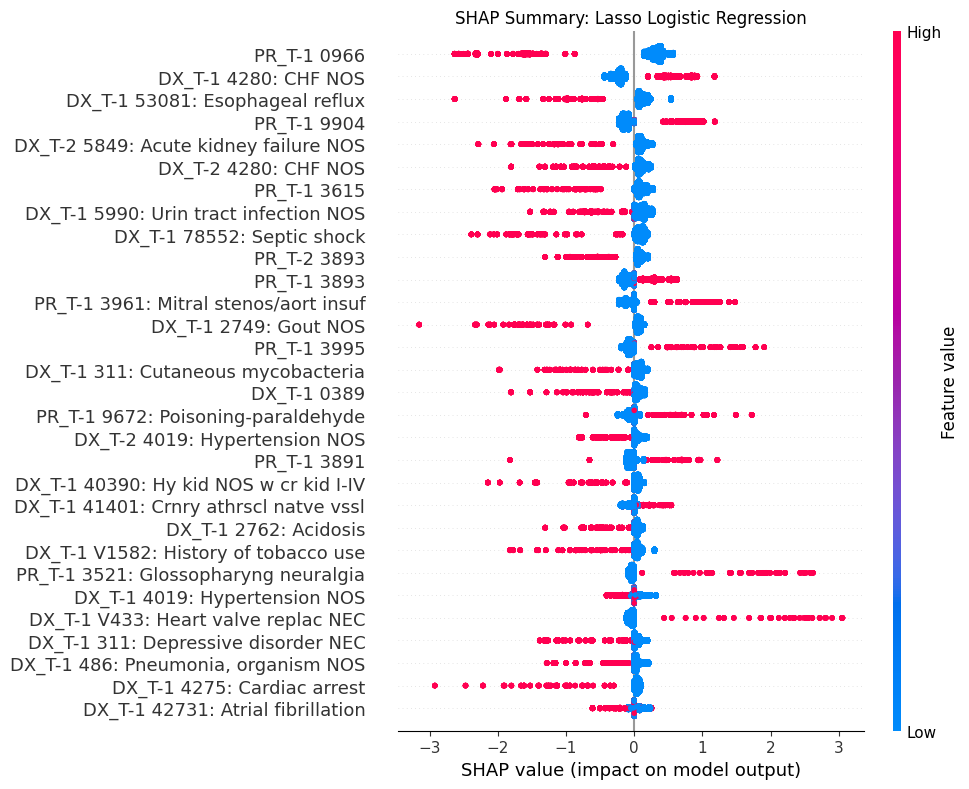

[PLOT] Saved 'shap_summary_lasso.png'
[DATA] Saved SHAP feature summary to 'shap_feature_summary_all_models.csv'

Top 15 mean |SHAP| features: XGBoost
                               Feature  XGBoost_mean_abs_SHAP
                                   Age               0.297708
                              LOS_DAYS               0.240412
                           DX_T-1 0383               0.000000
                           DX_T-1 0389               0.000000
                           DX_T-1 0414               0.000000
    DX_T-1 1560: Malig neo gallbladder               0.000000
   DX_T-1 1969: Mal neo lymph node NOS               0.000000
DX_T-1 25040: DMII renl nt st uncntrld               0.000000
 DX_T-1 2713: Disaccharidase def/malab               0.000000
 DX_T-1 2739: Dis plas protein met NOS               0.000000
                           PR_T-8 3722               0.000000
                 DX_T-1 2762: Acidosis               0.000000
                           DX_T-1 2848     

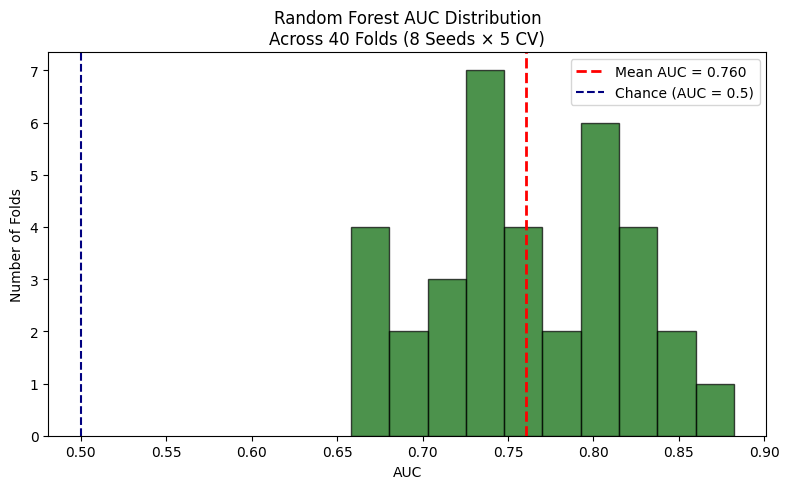

[PLOT] Saved 'rf_auc_histogram.png'

  PIPELINE COMPLETE!



In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from scipy import interpolate


print("\n" + "="*50)
print("  PHASE 10: MODEL EVALUATION & INTERPRETABILITY")
print("="*50 + "\n")

print("[EVAL] Calculating aggregated ROC/AUC across all cross-validation folds for all four models...")

roc_results = []
plt.figure(figsize=(8, 6))

for model_name, color in [('XGBoost', 'darkorange'), ('DecisionTree', 'steelblue'), ('RandomForest', 'mediumpurple'), ('Lasso', 'seagreen')]:
    y_true = np.asarray(model_predictions[model_name]['y'])
    y_prob = np.asarray(model_predictions[model_name]['probs'])

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    roc_results.append({'Model': model_name, 'Aggregated_ROC_AUC': roc_auc})
    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.3f})", color=color)
    print(f"[RESULT] {model_name} Aggregated ROC AUC: {roc_auc:.3f}")

roc_results_df = pd.DataFrame(roc_results).sort_values('Aggregated_ROC_AUC', ascending=False)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC For All Models (Averaged Across Folds and Seeds)')
plt.legend(loc='lower right')
plt.minorticks_on()
plt.grid(which='major', alpha=0.4, linewidth=1.0)
plt.grid(which='minor', alpha=0.5, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('final_roc_curve_all_models.png', dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

mean_fpr = np.linspace(0, 1, 100)
tprs = []

for i, (y_true, y_prob) in enumerate(rf_fold_roc_data):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    fold_auc = auc(fpr, tpr)
    
    # interpolate to common FPR grid
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    ax.plot(fpr, tpr, lw=0.8, alpha=0.3, color='green')  # no label


# Mean and confidence band
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_tpr = np.std(tprs, axis=0)

ax.plot(mean_fpr, mean_tpr, color='darkgreen', lw=2,
        label=f'Mean (AUC = {mean_auc:.3f} ± {np.std([auc(roc_curve(y,p)[0], roc_curve(y,p)[1]) for y,p in rf_fold_roc_data]):.3f})')
ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                alpha=0.2, color='green')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Random Forest (All Folds & Seeds)')
ax.legend(loc='lower right', fontsize=7)
ax.grid(which='major', alpha=0.4)
ax.grid(which='minor', alpha=0.2, linestyle='--')
plt.minorticks_on()
plt.tight_layout()
plt.savefig('roc_curve_rf_per_fold.png', dpi=300)
plt.show()
print("[PLOT] Saved 'roc_curve_rf_per_fold.png'")

print("\nAggregated ROC/AUC ranking:")
print(roc_results_df)
print("[PLOT] Saved ROC curve to 'final_roc_curve_all_models.png'")
print("[DATA] Saved aggregated ROC AUC table to 'aggregated_roc_auc_by_model.csv'")

# TOP 50 VISUALIZATION
top_50 = master_feat_df.sort_values('XGBoost', ascending=False).head(50)

fig, ax = plt.subplots(figsize=(12, 18))
top_50.set_index('Feature')['XGBoost'].sort_values().plot(kind='barh', color='teal', ax=ax)
ax.set_title('Top 50 Feature Importance - Bacterial Endocarditis')
ax.set_xlabel('Importance Score (XGBoost Average)')
ax.set_ylabel('Clinical Feature (Time + ICD-9 Description)')
plt.tight_layout()
plt.savefig('top_50_features_xgboost.png')
plt.show()

print("\n[PLOT] Saved 'top_50_features_xgboost.png' to disk.")

# SHAP Summary Plots
print("\n[INTERPRET] Generating SHAP summary plots for all four models (test-fold SHAP values)...")

def save_shap_summary_plot(shap_df, X_df, model_name, output_path, max_display=30):
    shap.summary_plot(
        shap_df.values,
        X_df.values,
        feature_names=X_df.columns.tolist(),
        max_display=max_display,
        show=False
    )
    fig = plt.gcf()
    fig.set_size_inches(10, 8)
    plt.title(f"SHAP Summary: {model_name}")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[PLOT] Saved '{output_path}'")

save_shap_summary_plot(final_shap_xgb_df, final_X_te_df, 'XGBoost', 'shap_summary_xgboost.png')
save_shap_summary_plot(final_shap_tree_df, final_X_te_df, 'Decision Tree', 'shap_summary_decision_tree.png')
save_shap_summary_plot(final_shap_rf_df, final_X_te_df, 'Random Forest', 'shap_summary_random_forest.png')
save_shap_summary_plot(final_shap_lasso_df, final_X_te_df, 'Lasso Logistic Regression', 'shap_summary_lasso.png')

def build_shap_rank_df(shap_df, model_name):
    ranked = np.abs(shap_df).mean(axis=0).sort_values(ascending=False)
    out = ranked.reset_index()
    out.columns = ['Feature', f'{model_name}_mean_abs_SHAP']
    return out

xgb_shap_rank_df = build_shap_rank_df(final_shap_xgb_df, 'XGBoost')
tree_shap_rank_df = build_shap_rank_df(final_shap_tree_df, 'DecisionTree')
rf_shap_rank_df = build_shap_rank_df(final_shap_rf_df, 'RandomForest')
lasso_shap_rank_df = build_shap_rank_df(final_shap_lasso_df, 'Lasso')

shap_report_df = (
    xgb_shap_rank_df
    .merge(tree_shap_rank_df, on='Feature', how='outer')
    .merge(rf_shap_rank_df, on='Feature', how='outer')
    .merge(lasso_shap_rank_df, on='Feature', how='outer')
    .fillna(0)
)

shap_report_df.to_csv('shap_feature_summary_all_models.csv', index=False)
print("[DATA] Saved SHAP feature summary to 'shap_feature_summary_all_models.csv'\n")

for model_name, shap_rank_df in [
    ('XGBoost', xgb_shap_rank_df),
    ('DecisionTree', tree_shap_rank_df),
    ('RandomForest', rf_shap_rank_df),
    ('Lasso', lasso_shap_rank_df),
]:
    print(f"Top 15 mean |SHAP| features: {model_name}")
    print(shap_rank_df.head(15).to_string(index=False))
    print()

# AUC Distribution Histogram — Random Forest
rf_aucs = fold_metrics_df[fold_metrics_df['Model'] == 'RandomForest']['AUC'].values

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(rf_aucs, bins=10, color='darkgreen', alpha=0.7, edgecolor='black')
ax.axvline(rf_aucs.mean(), color='red', linestyle='--', lw=2, 
           label=f'Mean AUC = {rf_aucs.mean():.3f}')
ax.axvline(0.5, color='navy', linestyle='--', lw=1.5,
           label='Chance (AUC = 0.5)')
ax.set_xlabel('AUC')
ax.set_ylabel('Number of Folds')
ax.set_title('Random Forest AUC Distribution\nAcross 40 Folds (8 Seeds × 5 CV)')
ax.legend()
plt.tight_layout()
plt.savefig('rf_auc_histogram.png', dpi=300)
plt.show()
print("[PLOT] Saved 'rf_auc_histogram.png'")

print("\n" + "="*50)
print("  PIPELINE COMPLETE!")
print("="*50 + "\n")

